# E-Commerce Customer Churn Prediction

**Dataset:** E-Commerce Customer Churn (5,630 customers, 20 features)  
**Goal:** Predict whether a customer will churn (leave) or stay  
**Models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting

## Section 1 – Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score)

%matplotlib inline
print('Libraries loaded successfully!')

Libraries loaded successfully!


## Section 2 – Upload and Load the Dataset

In [ ]:
from google.colab import files

print('Please upload E_Commerce_Dataset.xlsx')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print('Uploaded:', filename)

Please upload E_Commerce_Dataset.xlsx


Saving E Commerce Dataset.xlsx to E Commerce Dataset.xlsx
Uploaded: E Commerce Dataset.xlsx


In [ ]:
df_raw = pd.read_excel(filename, sheet_name='E Comm')

print('Dataset shape:', df_raw.shape)
df_raw.head()

Dataset shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Section 3 – Data Summary and Overview

In [ ]:
# Column info: data types, missing values, unique counts
overview = pd.DataFrame({
    'Dtype'  : df_raw.dtypes,
    'Nulls'  : df_raw.isnull().sum(),
    'Null %' : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Unique' : df_raw.nunique()
})
print(overview)

                               Dtype  Nulls  Null %  Unique
CustomerID                     int64      0    0.00    5630
Churn                          int64      0    0.00       2
Tenure                       float64    264    4.69      36
PreferredLoginDevice          object      0    0.00       3
CityTier                       int64      0    0.00       3
WarehouseToHome              float64    251    4.46      34
PreferredPaymentMode          object      0    0.00       7
Gender                        object      0    0.00       2
HourSpendOnApp               float64    255    4.53       6
NumberOfDeviceRegistered       int64      0    0.00       6
PreferedOrderCat              object      0    0.00       6
SatisfactionScore              int64      0    0.00       5
MaritalStatus                 object      0    0.00       3
NumberOfAddress                int64      0    0.00      15
Complain                       int64      0    0.00       2
OrderAmountHikeFromlastYear  float64    

In [ ]:
# Statistical summary
df_raw.describe().round(2)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52815.50,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,177.22
std,1625.39,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,49.21
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51408.25,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,52815.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.28
75%,54222.75,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.39
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,324.99


In [ ]:
# Check the target variable distribution
churn_counts = df_raw['Churn'].value_counts()
print('Churn distribution:')
print('Retained (0):', churn_counts[0], '=', round(churn_counts[0]/len(df_raw)*100, 1), '%')
print('Churned  (1):', churn_counts[1], '=', round(churn_counts[1]/len(df_raw)*100, 1), '%')
print('\nClass imbalance ratio:', round(churn_counts[0]/churn_counts[1], 1), ':1')

Churn distribution:
Retained (0): 4682 = 83.2 %
Churned  (1): 948 = 16.8 %

Class imbalance ratio: 4.9 :1


## Section 4 – Exploratory Data Analysis (EDA)

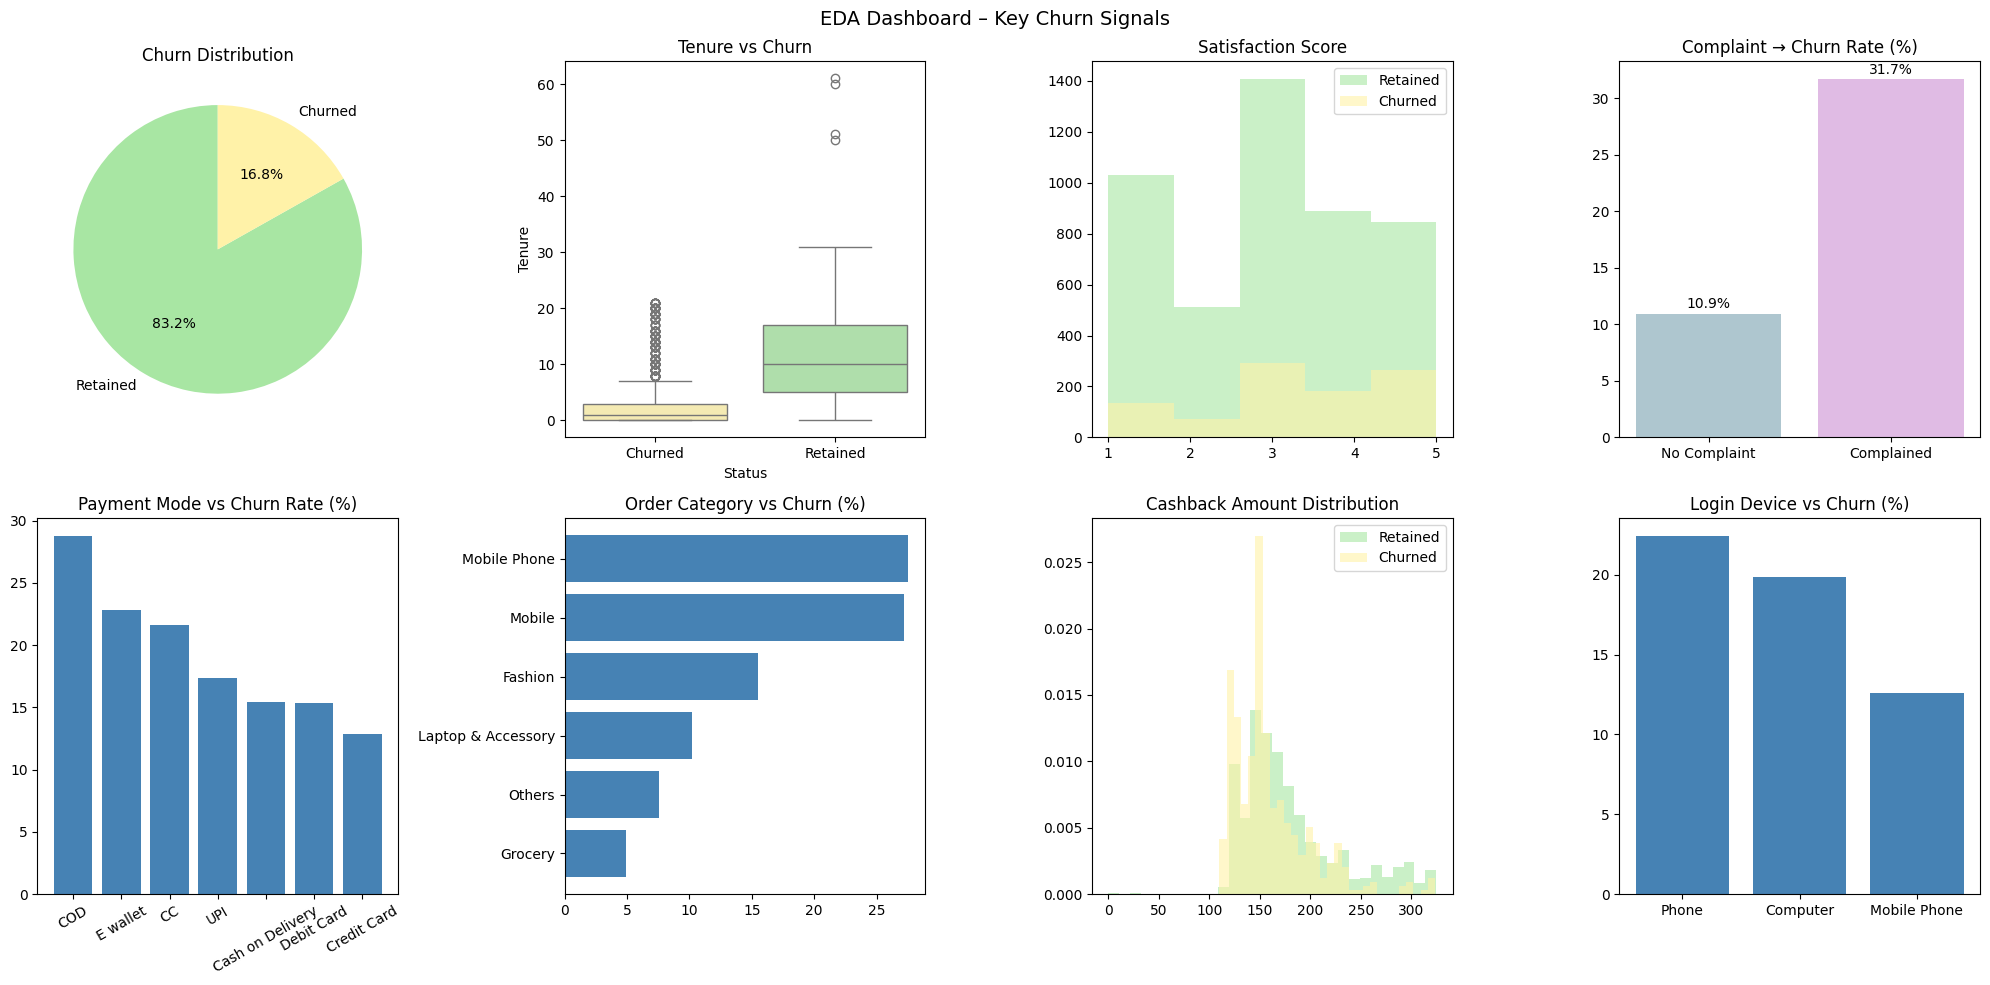

In [ ]:
df = df_raw.copy()  #creates a safe working copy of your dataset so we don’t modify the original

# creating the dashboard layout:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('EDA Dashboard – Key Churn Signals', fontsize=14)
axes = axes.flatten()

# 1 – Churn distribution (pie chart)
axes[0].pie([churn_counts[0], churn_counts[1]],
            labels=['Retained', 'Churned'],
            colors=['#A8E6A3', '#FFF2A8'],
            autopct='%1.1f%%', startangle=90)   #shows percentage of retained vs churned customers
axes[0].set_title('Churn Distribution')

# 2 – Tenure vs Churn
df_box = df[['Churn', 'Tenure']].copy()
df_box['Status'] = df_box['Churn'].map({0: 'Retained', 1: 'Churned'})
sns.boxplot(data=df_box, x='Status', y='Tenure', ax=axes[1],
            palette={'Retained': '#A8E6A3', 'Churned': '#FFF2A8'})
axes[1].set_title('Tenure vs Churn')

# 3 – Satisfaction Score
for v, c, l in [(0, '#A8E6A3', 'Retained'), (1, '#FFF2A8', 'Churned')]:
    axes[2].hist(df[df['Churn'] == v]['SatisfactionScore'],
                 bins=5, alpha=0.6, color=c, label=l)
axes[2].set_title('Satisfaction Score')
axes[2].legend()

# 4 – Complaint impact
cc = df.groupby('Complain')['Churn'].mean() * 100
axes[3].bar(['No Complaint', 'Complained'], [cc[0], cc[1]],
            color=['#AEC6CF', '#E0BBE4'])
axes[3].set_title('Complaint → Churn Rate (%)')
for i, val in enumerate([cc[0], cc[1]]):
    axes[3].text(i, val + 0.5, f'{val:.1f}%', ha='center')

# 5 – Payment mode
pay_churn = df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False) * 100
axes[4].bar(pay_churn.index, pay_churn.values, color='steelblue')
axes[4].set_title('Payment Mode vs Churn Rate (%)')
axes[4].tick_params(axis='x', rotation=30)

# 6 – Order category
cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values() * 100
axes[5].barh(cat_churn.index, cat_churn.values, color='steelblue')
axes[5].set_title('Order Category vs Churn (%)')

# 7 – Cashback distribution
for v, c, l in [(0, '#A8E6A3', 'Retained'), (1, '#FFF2A8', 'Churned')]:
    axes[6].hist(df[df['Churn'] == v]['CashbackAmount'],
                 bins=30, alpha=0.6, color=c, label=l, density=True)
axes[6].set_title('Cashback Amount Distribution')
axes[6].legend()

# 8 – Login device
dev_churn = df.groupby('PreferredLoginDevice')['Churn'].mean().sort_values(ascending=False) * 100
axes[7].bar(dev_churn.index, dev_churn.values, color='steelblue')
axes[7].set_title('Login Device vs Churn (%)')

plt.tight_layout()
plt.show()

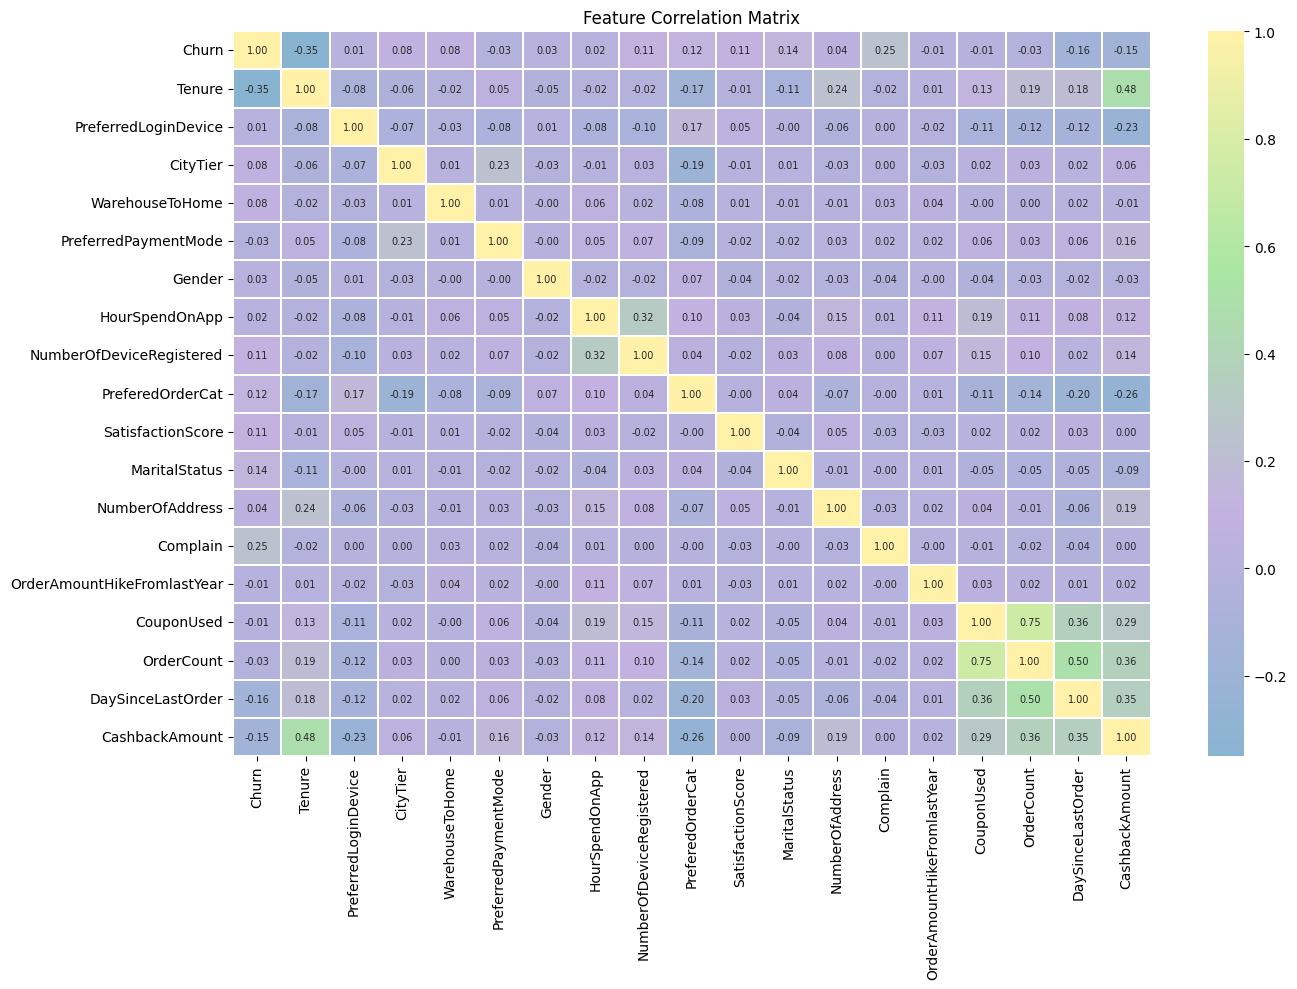

In [ ]:
# c – encode categoricals first
df_enc = df.copy()
le_tmp = LabelEncoder()
for c in df_enc.select_dtypes(include='object').columns:
    df_enc[c] = le_tmp.fit_transform(df_enc[c].astype(str))

num_cols = [c for c in df_enc.select_dtypes(include='number').columns if c != 'CustomerID']
corr = df_enc[num_cols].corr()

# Build custom colormap from your palette
custom_cmap = LinearSegmentedColormap.from_list(
    'custom', ['#89B4D1', '#C3B1E1', '#A8E6A3', '#FFF2A8']
)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=custom_cmap,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Section 5 – Data Preprocessing & Feature Engineering

In [ ]:
# ─────────────────────────────────────────────────────────────
# DATA PREPROCESSING & FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

# Drop the CustomerID column since it's a unique identifier that carries no predictive value for the model. We use .copy() to avoid modifying the original DataFrame (df) — all changes will be made on df_clean.
df = df_raw.copy()
df_clean = df.drop(columns=['CustomerID']).copy()


# ── Step 0: Flag Missing Values BEFORE Imputation ─────────────
# Before filling any missing values, we extract the information hidden inside them by creating binary flag columns (0 or 1).
# Why? Because a missing value is not always just a data error — sometimes it carries meaning.

cols_to_flag = ['DaySinceLastOrder', 'Tenure', 'OrderCount']
# We flag these 3 specifically because their missingness has a plausible business meaning (never ordered, new/unknown customer,
# no recorded orders). The other missing columns are more likely random data gaps.

print('Step 0: Creating missing-value flags')
for col in cols_to_flag:
    flag_col = f'{col}_WasMissing'
    df_clean[flag_col] = df_clean[col].isnull().astype(int)  # 1 = was missing, 0 = had a value
    n_flagged = df_clean[flag_col].sum()
    print(f'  {flag_col}: {n_flagged} customers flagged ({n_flagged/len(df_clean)*100:.1f}%)')

# Quick business check: do flagged customers churn more?
# This validates whether our flags actually carry predictive signal.
print('\n  Churn rate validation for flags:')
for col in cols_to_flag:
    flag_col = f'{col}_WasMissing'
    churn_flagged     = df_clean[df_clean[flag_col] == 1]['Churn'].mean() * 100
    churn_not_flagged = df_clean[df_clean[flag_col] == 0]['Churn'].mean() * 100
    print(f'  {flag_col}:')
    print(f'    Flagged (was missing) → churn rate: {churn_flagged:.1f}%')
    print(f'    Not flagged           → churn rate: {churn_not_flagged:.1f}%')


# ── Step 1: Median Imputation for Missing Values ──────────────
# NOW we fill the missing values — after the flags are already saved.
# We use the median instead of the mean because the median is more robust to outliers in skewed distributions
num_impute = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
              'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

print('\nStep 1: Median imputation')
for col in num_impute:
    med = df_clean[col].median()               # Compute the median (ignores NaNs)
    df_clean[col] = df_clean[col].fillna(med)  # Replace NaNs with that median value
    print(f'  {col} -> median = {med:.2f}')    # Log the imputed value for transparency


# ── Step 2: Label Encoding for Categorical Columns ───────────
# Machine learning models require numerical input. Here we convert all text/categorical columns to integer codes.
# We store each encoder in le_dict so we can inverse-transform predictions later.
# Note: Label Encoding assigns arbitrary integer codes which implies an ordinal relationship that may not exist
# (pd.get_dummies) for nominal features — we use Label Encoding here for simplicity.
print('\nStep 2: Label encoding')
cat_features = df_clean.select_dtypes(include='object').columns.tolist()  # Auto-detect categoricals
le_dict = {}
for col in cat_features:
    le_col = LabelEncoder()                                        # Fresh encoder per column
    df_clean[col] = le_col.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le_col                                         # Save encoder for later use
    print(f'  {col} -> {list(le_col.classes_)}')

print(f'\nFinal shape after preprocessing: {df_clean.shape}')
print(f'New flag columns added: {[c for c in df_clean.columns if "WasMissing" in c]}')

Step 0: Creating missing-value flags
  DaySinceLastOrder_WasMissing: 307 customers flagged (5.5%)
  Tenure_WasMissing: 264 customers flagged (4.7%)
  OrderCount_WasMissing: 258 customers flagged (4.6%)

  Churn rate validation for flags:
  DaySinceLastOrder_WasMissing:
    Flagged (was missing) → churn rate: 17.6%
    Not flagged           → churn rate: 16.8%
  Tenure_WasMissing:
    Flagged (was missing) → churn rate: 30.7%
    Not flagged           → churn rate: 16.2%
  OrderCount_WasMissing:
    Flagged (was missing) → churn rate: 7.0%
    Not flagged           → churn rate: 17.3%

Step 1: Median imputation
  Tenure -> median = 9.00
  WarehouseToHome -> median = 14.00
  HourSpendOnApp -> median = 3.00
  OrderAmountHikeFromlastYear -> median = 15.00
  CouponUsed -> median = 1.00
  OrderCount -> median = 2.00
  DaySinceLastOrder -> median = 3.00

Step 2: Label encoding
  PreferredLoginDevice -> ['Computer', 'Mobile Phone', 'Phone']
  PreferredPaymentMode -> ['CC', 'COD', 'Cash on Deli

## Section 6 – Train/Test Split and Feature Scaling

In [ ]:
# ─────────────────────────────────────────────────────────────
# TRAIN/TEST SPLIT & FEATURE SCALING
# ─────────────────────────────────────────────────────────────

# Separate the dataset into:
#   X → input features (everything except the target column)
#   y → target variable (Churn: 1 = churned, 0 = retained)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']


# ── Train / Test Split ────────────────────────────────────────
# We split the data into 80% training and 20% testing.
# 'stratify=y' ensures both subsets preserve the same churn ratio as the full dataset — important when the target classes are imbalanced,so the model doesn't train or evaluate on a skewed distribution.
#'random_state=42' fixes the random seed for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Verify that the churn rate is consistent across both splits
print('Train size:', X_train.shape[0], '| Churn rate:', round(y_train.mean()*100, 2), '%')
print('Test size: ', X_test.shape[0],  '| Churn rate:', round(y_test.mean()*100,  2), '%')
print('Features: ', X_train.shape[1])


# ── Feature Scaling with RobustScaler ────────────────────────
# Some models (like Logistic Regression) are sensitive to the scale of input features.
# RobustScaler centers each feature using the median and scales it by the Interquartile Range (IQR), making it resistant to outliers unlike StandardScaler (which uses mean and std, both skewed by extreme values).
# Important: We fit the scaler ONLY on the training set, then apply (transform)it to the test set. Fitting on the full dataset would cause data leakage —the model would indirectly "see" test data during training.
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit on train, then transform
X_test_sc  = scaler.transform(X_test)       # Transform only — never fit on test data

# Sanity check: after scaling, values should be centered near 0 with a standard deviation close to 1 (not exact due to IQR-based scaling)
print('\nRobustScaler applied (used only for Logistic Regression)')
print('Train mean after scaling:', round(X_train_sc.mean(), 4))
print('Train std after scaling: ', round(X_train_sc.std(),  4))

Train size: 4504 | Churn rate: 16.83 %
Test size:  1126 | Churn rate: 16.87 %
Features:  21

RobustScaler applied (used only for Logistic Regression)
Train mean after scaling: 0.1083
Train std after scaling:  0.8869


## Section 7 – Model Training (Baseline)

In [ ]:
# ─────────────────────────────────────────────────────────────
# BASELINE MODEL TRAINING & EVALUATION
# ─────────────────────────────────────────────────────────────

# Define 4 classifiers to compare against each other as baselines.
# All models use random_state=42 for reproducibility.
# Settings are intentionally kept at (or close to) defaults at this stage
# Brief notes on each:
#   - LogisticRegression : linear model; max_iter=1000 ensures convergence on larger datasets
#   - DecisionTreeClassifier : single tree; tends to overfit but useful as a reference
#   - RandomForestClassifier : ensemble of 100 trees; n_jobs=-1 uses all CPU cores in parallel
#   - GradientBoostingClassifier : boosted ensemble of 100 trees; typically strong out-of-the-box
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Dictionary to store each model's trained object, predictions, and metrics so they can be accessed and compared after the loop.
results = {}

# StratifiedKFold splits the training data into 5 folds for cross-validation while preserving the churn ratio in each fold (same idea as stratify in train_test_split).
# shuffle=True randomizes the data before splitting to avoid ordering bias.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training baseline models...')
print('-' * 60)

for name, model in models.items():

    # ── Select the correct input data per model ───────────────
    # Logistic Regression requires scaled features (X_train_sc / X_test_sc).
    # Tree-based models are scale-invariant, so we pass raw values instead.
    # .values converts the DataFrame to a NumPy array, which some sklearn
    # internals prefer for speed and compatibility.
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train.values
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test.values

    # ── Train the model ───────────────────────────────────────
    model.fit(Xtr, y_train)

    # ── Generate predictions ──────────────────────────────────
    # predict()       → hard class labels (0 or 1) used for accuracy, F1, etc.
    # predict_proba() → probability scores; [:, 1] selects the probability of
    #                   the positive class (Churn = 1), used for ROC-AUC.
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    # ── Compute evaluation metrics ────────────────────────────
    # We use multiple metrics because no single metric tells the full story,
    # especially on imbalanced datasets like churn:
    #
    #   Accuracy  : % of correct predictions overall (misleading if classes are imbalanced)
    #   ROC-AUC   : ability to distinguish churners from non-churners across all thresholds;
    #               0.5 = random, 1.0 = perfect
    #   F1 Score  : harmonic mean of Precision and Recall — good for imbalanced classes
    #   Precision : of all predicted churners, how many actually churned?
    #   Recall    : of all actual churners, how many did the model catch?
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    # ── Cross-validation on training data ─────────────────────
    # Cross-validation gives a more reliable estimate of model performance by training/evaluating across 5 different data splits.
    # We report the mean AUC and standard deviation across the 5 folds.
    cvs = cross_val_score(model, Xtr, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

    # ── Store all results for later comparison ────────────────
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'roc_auc': roc, 'f1': f1,
        'precision': prec, 'recall': rec,
        'cv_mean': cvs.mean(), 'cv_std': cvs.std(),
        'Xtr': Xtr, 'Xte': Xte
    }

    # ── Print a summary for this model ───────────────────────
    # cv_std reflects consistency: a low std means the model performs reliably regardless of which data subset it's trained on.
    print(f'\n{name}')
    print(f'  Accuracy : {acc*100:.2f}%  |  ROC-AUC: {roc:.4f}  |  F1: {f1:.4f}')
    print(f'  Precision: {prec:.4f}      |  Recall : {rec:.4f}')
    print(f'  CV AUC   : {cvs.mean():.4f} +/- {cvs.std():.4f}')

Training baseline models...
------------------------------------------------------------

Logistic Regression
  Accuracy : 88.01%  |  ROC-AUC: 0.8672  |  F1: 0.5631
  Precision: 0.7311      |  Recall : 0.4579
  CV AUC   : 0.8801 +/- 0.0130

Decision Tree
  Accuracy : 96.18%  |  ROC-AUC: 0.9330  |  F1: 0.8871
  Precision: 0.8848      |  Recall : 0.8895
  CV AUC   : 0.8808 +/- 0.0102

Random Forest
  Accuracy : 98.13%  |  ROC-AUC: 0.9989  |  F1: 0.9421
  Precision: 0.9884      |  Recall : 0.9000
  CV AUC   : 0.9751 +/- 0.0073

Gradient Boosting
  Accuracy : 91.65%  |  ROC-AUC: 0.9439  |  F1: 0.7235
  Precision: 0.8200      |  Recall : 0.6474
  CV AUC   : 0.9309 +/- 0.0155


In [ ]:
# Classification report for each model
for name, res in results.items():
    print(f'\n{name}')
    print(classification_report(y_test, res['y_pred'], target_names=['Retained', 'Churned']))


Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.97      0.93       936
     Churned       0.73      0.46      0.56       190

    accuracy                           0.88      1126
   macro avg       0.81      0.71      0.75      1126
weighted avg       0.87      0.88      0.87      1126


Decision Tree
              precision    recall  f1-score   support

    Retained       0.98      0.98      0.98       936
     Churned       0.88      0.89      0.89       190

    accuracy                           0.96      1126
   macro avg       0.93      0.93      0.93      1126
weighted avg       0.96      0.96      0.96      1126


Random Forest
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       936
     Churned       0.99      0.90      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.97      1126
weighted avg       0.98

## Section 8 – Model Evaluation and Comparison

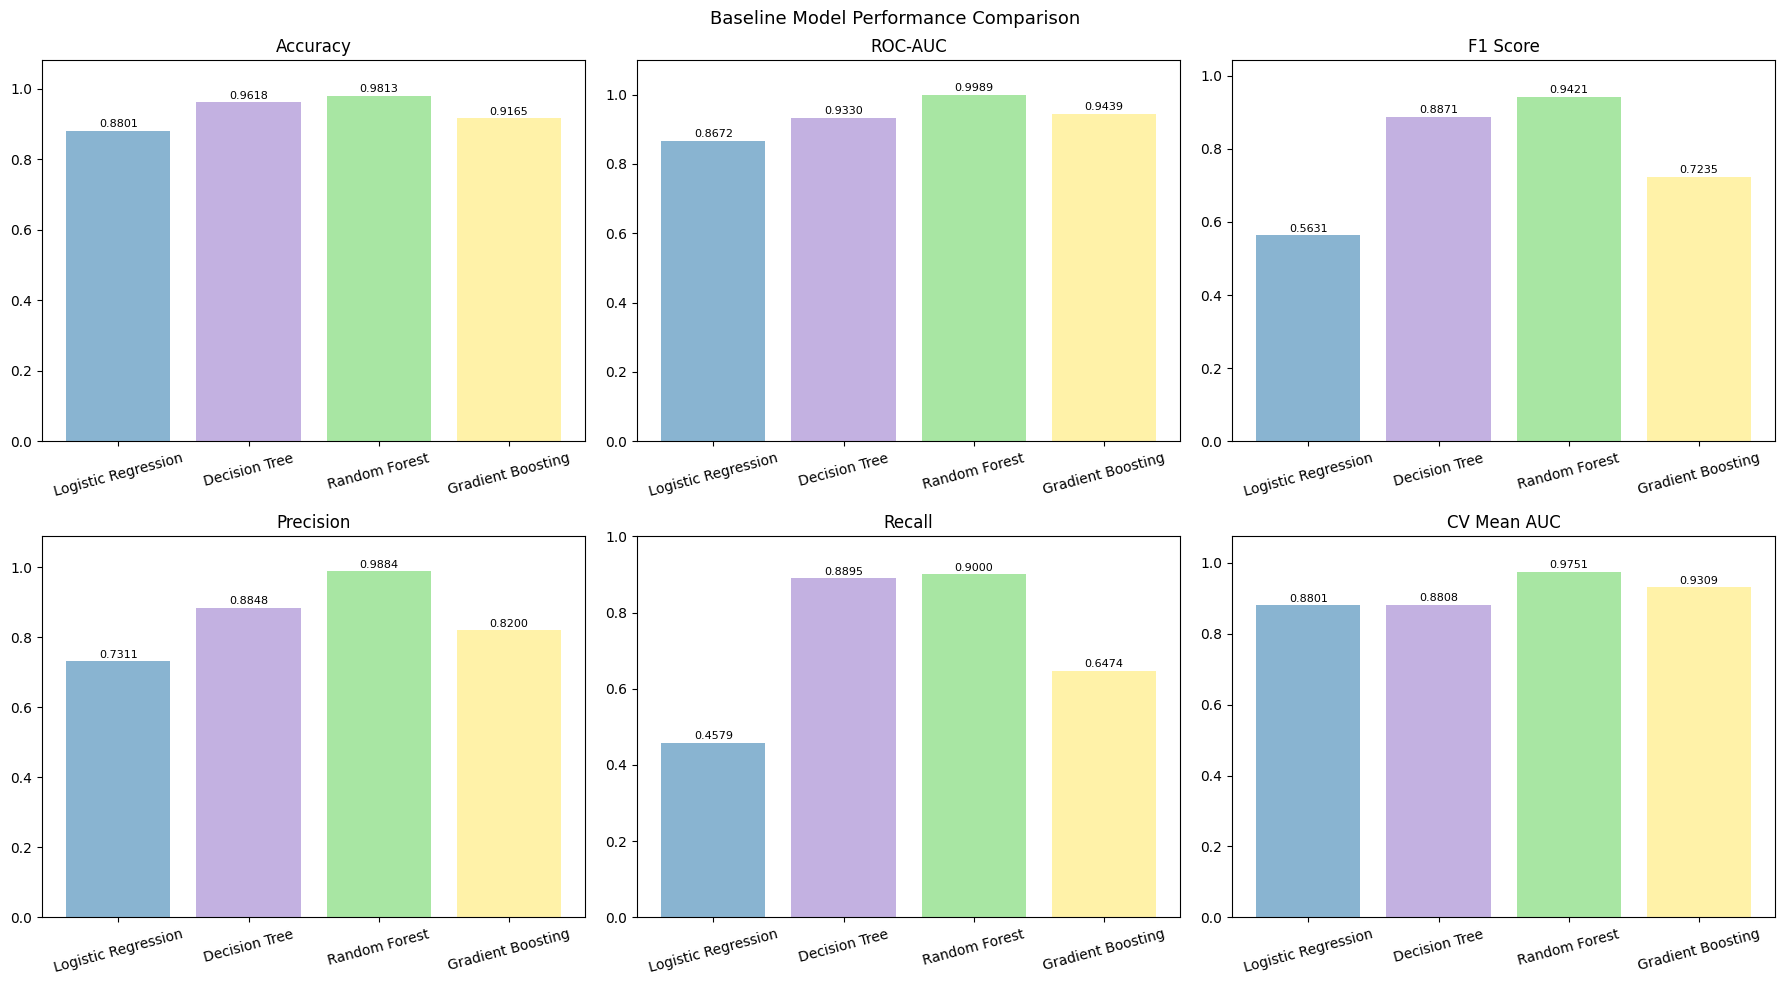

In [ ]:
# ─────────────────────────────────────────────────────────────
# BASELINE MODEL PERFORMANCE – BAR CHART COMPARISON
# ─────────────────────────────────────────────────────────────


model_colors = ['#89B4D1', '#C3B1E1', '#A8E6A3', '#FFF2A8']

# Create a 2×3 grid of subplots — one panel per evaluation metric.
# figsize=(18, 10) gives enough horizontal space to avoid label overlap.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Baseline Model Performance Comparison', fontsize=13)

# Flatten the 2D array of axes into a 1D list so we can iterate over subplots with a simple index instead of [row][col] notation.
axes = axes.flatten()

# Each tuple contains: (results dict key, human-readable subplot title)
# The 6 metrics cover different angles of model quality (see training block for definitions)
metric_pairs = [('accuracy', 'Accuracy'), ('roc_auc', 'ROC-AUC'), ('f1', 'F1 Score'),
                ('precision', 'Precision'), ('recall', 'Recall'), ('cv_mean', 'CV Mean AUC')]

for i, (metric, title) in enumerate(metric_pairs):

    # Extract model names and their corresponding metric values for this subplot
    names  = list(results.keys())
    values = [results[n][metric] for n in names]

    # Draw the bar chart for this metric
    bars = axes[i].bar(names, values, color=model_colors)
    axes[i].set_title(title)

    # Set y-axis upper limit to whichever is smaller: 1.1 (max possible) or the highest bar + 0.1 padding — keeps bars from touching the top edge.
    axes[i].set_ylim(0, min(1.1, max(values) + 0.1))

    # Rotate x-axis labels slightly to prevent overlapping model names
    axes[i].tick_params(axis='x', rotation=15)

    # Annotate each bar with its exact numeric value, positioned just above the top of the bar (bar.get_height() + 0.005).
    # ha='center' aligns the label to the middle of the bar horizontally.
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Automatically adjust subplot spacing to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

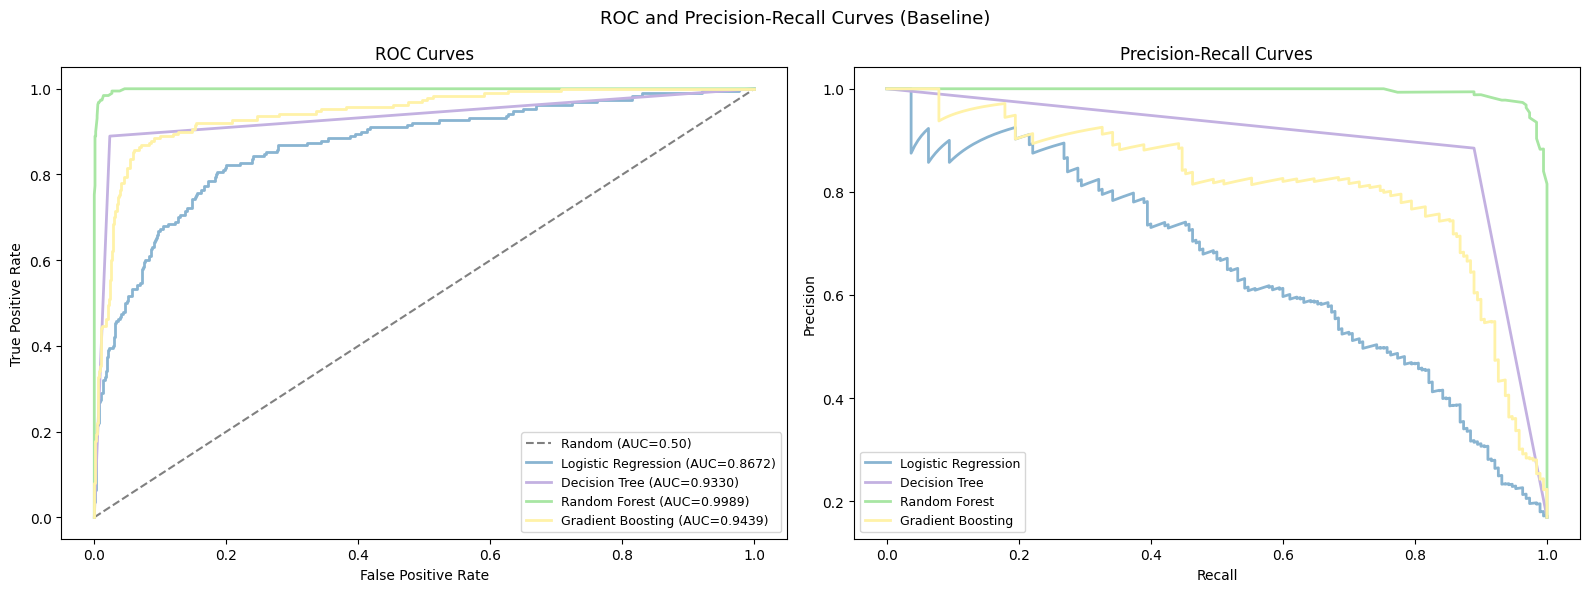

In [ ]:
# ─────────────────────────────────────────────────────────────
# ROC CURVES & PRECISION-RECALL CURVES (BASELINE MODELS)
# ─────────────────────────────────────────────────────────────
# These two plots go beyond single-number metrics by showing model performance across ALL classification thresholds, not just the default 0.5.


model_colors = ['#89B4D1', '#C3B1E1', '#A8E6A3', '#FFF2A8']

# Create two side-by-side subplots: one for ROC, one for Precision-Recall
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC and Precision-Recall Curves (Baseline)', fontsize=13)

# ── ROC Curve Plot ────────────────────────────────────────────
# The diagonal dashed line represents a random classifier (AUC = 0.50) — any model curve above this line is performing better than random chance.
# It serves as the baseline reference for visual comparison.
ax_roc.plot([0, 1], [0, 1], ls='--', color='gray', label='Random (AUC=0.50)')

for (name, res), color in zip(results.items(), model_colors):

    # roc_curve() returns:
    #   fpr → False Positive Rate (x-axis): how often the model wrongly flags non-churners
    #   tpr → True Positive Rate (y-axis): how often the model correctly catches churners
    # A good model hugs the top-left corner (high TPR, low FPR).
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])

    # precision_recall_curve() returns:
    #   prec_c → Precision at each threshold: of predicted churners, how many truly churned?
    #   rec_c  → Recall at each threshold: of actual churners, how many were caught?
    # This curve is especially informative when classes are imbalanced — a model can look great on ROC but poorly on PR if it struggles with the minority class.
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_proba'])

    # Plot each model's ROC curve with its AUC score in the legend
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={res["roc_auc"]:.4f})')

    # Plot each model's Precision-Recall curve (no AUC shown here — visual shape is the focus)
    ax_pr.plot(rec_c, prec_c, color=color, lw=2, label=name)

# ── ROC Axis Labels & Legend ──────────────────────────────────
ax_roc.set_title('ROC Curves')
ax_roc.set_xlabel('False Positive Rate')   # X: false alarms (non-churners predicted as churners)
ax_roc.set_ylabel('True Positive Rate')    # Y: correctly identified churners
ax_roc.legend(fontsize=9)

# ── Precision-Recall Axis Labels & Legend ────────────────────
# A curve that stays high on both axes indicates a strong model.
# A steep drop in precision as recall increases signals many false positives.
ax_pr.set_title('Precision-Recall Curves')
ax_pr.set_xlabel('Recall')      # X: coverage of actual churners
ax_pr.set_ylabel('Precision')   # Y: reliability of churn predictions
ax_pr.legend(fontsize=9)

# Adjust layout so titles and axis labels don't overlap between subplots
plt.tight_layout()
plt.show()

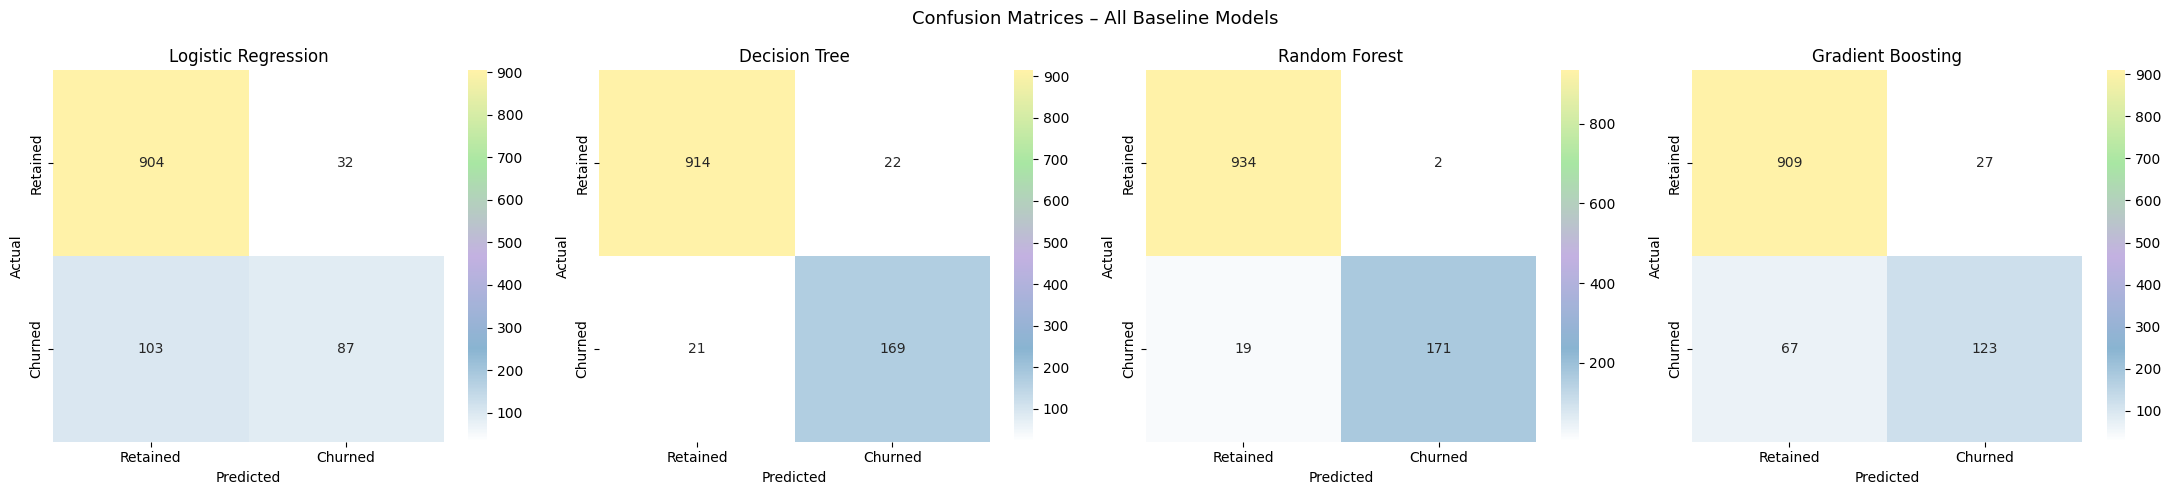

In [ ]:
# ─────────────────────────────────────────────────────────────
# CONFUSION MATRICES – ALL BASELINE MODELS
# ─────────────────────────────────────────────────────────────
# A confusion matrix breaks down predictions into 4 categories:
#
#   True Negative  (TN) | False Positive (FP)
#   False Negative (FN) | True Positive  (TP)
#
#   TN → correctly predicted "Retained"   (non-churner caught)
#   TP → correctly predicted "Churned"    (churner caught)
#   FP → predicted "Churned" but was "Retained"  (false alarm)
#   FN → predicted "Retained" but actually churned (missed churner)
#
# In a churn context, FN is typically the more costly error — a missed churner means lost revenue with no intervention attempt.

pastel_cmap = LinearSegmentedColormap.from_list(
    'pastel_theme', ['#ffffff', '#89B4D1', '#C3B1E1', '#A8E6A3', '#FFF2A8']
)

# Create a 1×4 grid — one confusion matrix per model
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices – All Baseline Models', fontsize=13)

for i, (name, res) in enumerate(results.items()):

    # Compute the confusion matrix by comparing true labels vs predicted labels
    cm = confusion_matrix(y_test, res['y_pred'])

    # Render as a heatmap for easy visual interpretation:
    #   annot=True     → display the raw counts inside each cell
    #   fmt='d'        → format numbers as integers (not scientific notation)
    #   pastel_cmap    → custom gradient from white to lilac for theme consistency
    sns.heatmap(cm, annot=True, fmt='d', cmap=pastel_cmap, ax=axes[i],
                xticklabels=['Retained', 'Churned'],   # Predicted class labels (x-axis)
                yticklabels=['Retained', 'Churned'])   # Actual class labels (y-axis)

    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')  # What the model predicted
    axes[i].set_ylabel('Actual')     # The ground truth label

# Adjust spacing so heatmaps and labels don't overlap across subplots
plt.tight_layout()
plt.show()

## Section 9 – Hyperparameter Tuning (GridSearchCV)

**Note:** This takes 5–15 minutes on Colab.

In [ ]:
# Our baseline models used default settings. Tuning means we systematically
# test different parameter combinations and pick the best-performing one.
#
# GridSearchCV:
#   → Tries every combination in the parameter grid
#   → Evaluates each using 5-fold cross-validation
#   → Scores each using ROC-AUC (handles imbalanced data better than accuracy)
#   → Automatically refits the best model on the full training set
#
# ⚠️ This takes 5–15 minutes on Colab — that's expected, don't interrupt it.

param_grids = {
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10],   # Regularization: lower C = simpler model, less overfitting
        'penalty': ['l2'],                # L2 penalizes large coefficients
        'solver' : ['lbfgs']              # Optimization algorithm suited for medium datasets
    },
    'Decision Tree': {
        'max_depth'        : [4, 6, 8, 10, None],   # Deeper = more complex = higher overfitting risk
        'min_samples_split': [2, 5, 10],             # Min samples needed to split a node
        'min_samples_leaf' : [1, 2, 4],              # Min samples required at leaf nodes
        'criterion'        : ['gini', 'entropy']     # Split quality measure
    },
    'Random Forest': {
        'n_estimators'     : [50, 100, 200],         # Number of trees: more = more stable, slower
        'max_depth'        : [6, 8, 10],             # Max depth per tree
        'min_samples_split': [2, 5],                 # Min samples to split a node
        'max_features'     : ['sqrt', 'log2']        # Features considered per split — controls tree diversity
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200],                 # Number of sequential trees
        'learning_rate': [0.05, 0.1, 0.2],           # Contribution of each tree: smaller = more conservative
        'max_depth'    : [3, 4, 5],                  # Shallow trees are typical for boosting
        'subsample'    : [0.8, 1.0]                  # Fraction of samples per tree — adds randomness
    },
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
}

tuned_results   = {}
best_params_all = {}

print('Hyperparameter Tuning – GridSearchCV (scoring=roc_auc, cv=5)')
print('-' * 60)

for name, base_model in base_models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train.values
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test.values

    print(f'\nTuning {name} ...')

    grid = GridSearchCV(
        base_model, param_grids[name],
        cv=5,              # 5-fold cross-validation per combination
        scoring='roc_auc', # Primary metric for model selection
        n_jobs=-1,         # Use all CPU cores to speed up search
        verbose=0,         # Suppress per-fold logs
        refit=True         # Refit best model on full training data automatically
    )
    grid.fit(Xtr, y_train)

    best_model = grid.best_estimator_
    y_pred_t   = best_model.predict(Xte)
    y_proba_t  = best_model.predict_proba(Xte)[:, 1]

    acc_t = accuracy_score(y_test, y_pred_t)
    roc_t = roc_auc_score(y_test, y_proba_t)
    f1_t  = f1_score(y_test, y_pred_t)

    tuned_results[name] = {
        'model': best_model, 'y_pred': y_pred_t, 'y_proba': y_proba_t,
        'accuracy': acc_t, 'roc_auc': roc_t, 'f1': f1_t,
        'best_score': grid.best_score_
    }
    best_params_all[name] = grid.best_params_

    print(f'  Best params : {grid.best_params_}')
    print(f'  CV Best AUC : {grid.best_score_:.4f}')
    print(f'  Test Accuracy: {acc_t*100:.2f}%  |  ROC-AUC: {roc_t:.4f}  |  F1: {f1_t:.4f}')




Hyperparameter Tuning – GridSearchCV (scoring=roc_auc, cv=5)
------------------------------------------------------------

Tuning Logistic Regression ...
  Best params : {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
  CV Best AUC : 0.8806
  Test Accuracy: 88.01%  |  ROC-AUC: 0.8672  |  F1: 0.5631

Tuning Decision Tree ...
  Best params : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
  CV Best AUC : 0.9069
  Test Accuracy: 92.63%  |  ROC-AUC: 0.9582  |  F1: 0.7662

Tuning Random Forest ...
  Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  CV Best AUC : 0.9664
  Test Accuracy: 94.76%  |  ROC-AUC: 0.9885  |  F1: 0.8207

Tuning Gradient Boosting ...
  Best params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
  CV Best AUC : 0.9740
  Test Accuracy: 98.76%  |  ROC-AUC: 0.9988  |  F1: 0.9624


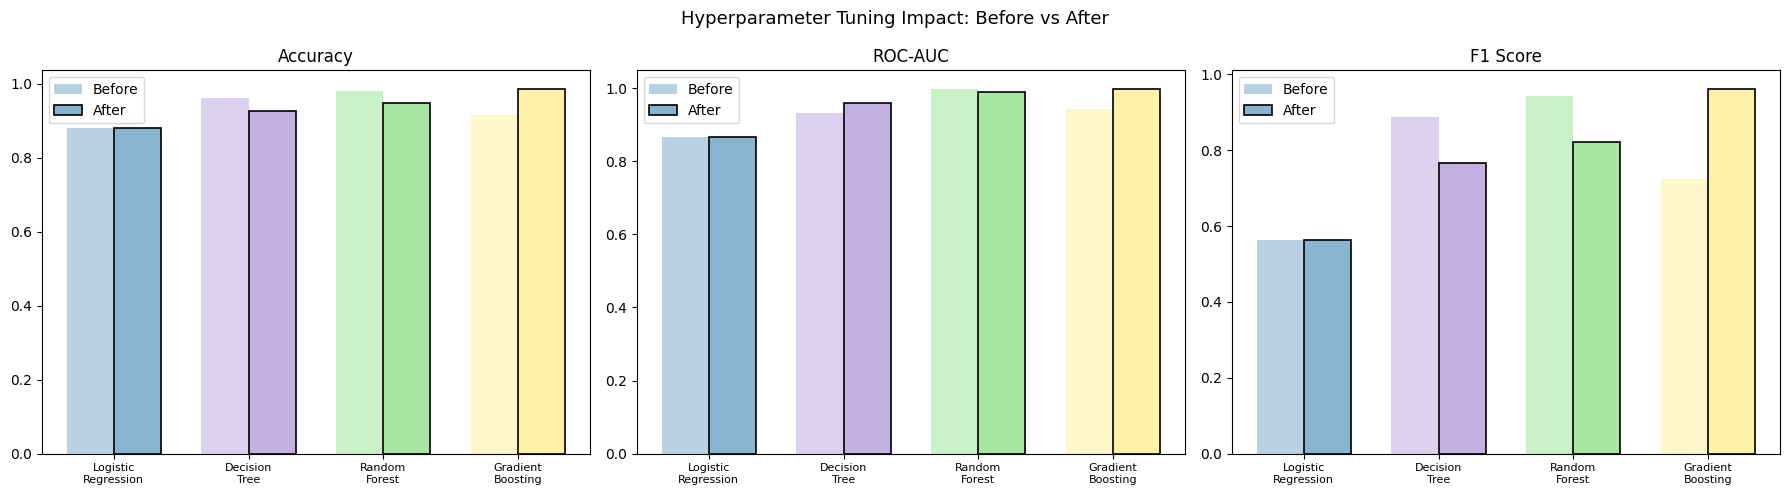

In [ ]:
# ── Before vs After Tuning Comparison ─────────────────────────────────────
# This chart directly answers: did tuning actually help?
# A visible gap between "before" (translucent) and "after" (solid) bars
# confirms that default parameters were suboptimal.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hyperparameter Tuning Impact: Before vs After', fontsize=13)

names = list(results.keys())
x     = np.arange(len(names))
w     = 0.35

for i, (metric, title) in enumerate([('accuracy', 'Accuracy'),
                                       ('roc_auc', 'ROC-AUC'),
                                       ('f1', 'F1 Score')]):
    before = [results[n][metric]       for n in names]  # Baseline results
    after  = [tuned_results[n][metric] for n in names]  # Tuned results

    axes[i].bar(x - w/2, before, w, label='Before', alpha=0.6, color=model_colors)
    axes[i].bar(x + w/2, after,  w, label='After',  alpha=1.0, color=model_colors,
                edgecolor='black', linewidth=1.2)
    axes[i].set_title(title)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    axes[i].legend()

plt.tight_layout()
plt.show()



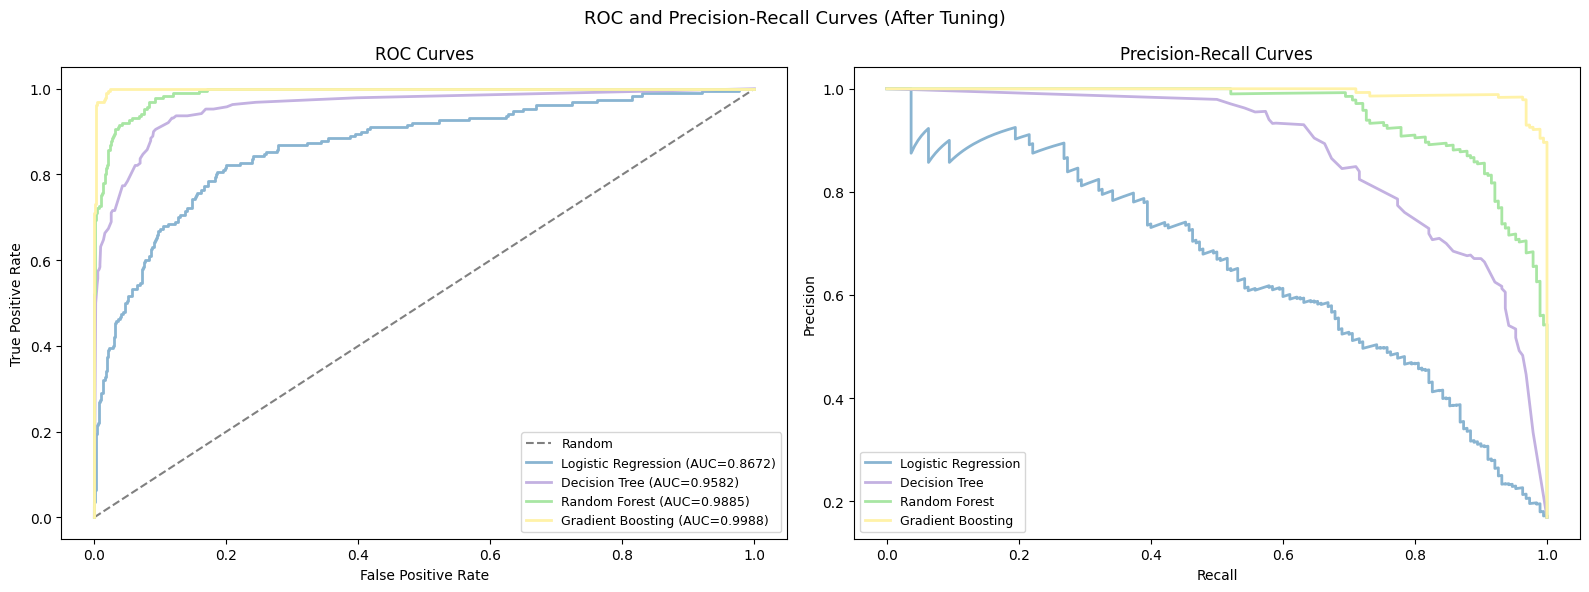

In [ ]:
# ROC curves after tuning
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC and Precision-Recall Curves (After Tuning)', fontsize=13)

ax_roc.plot([0, 1], [0, 1], ls='--', color='gray', label='Random')

for (name, res), color in zip(tuned_results.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_proba'])

    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={res["roc_auc"]:.4f})')
    ax_pr.plot(rec_c, prec_c, color=color, lw=2, label=name)

ax_roc.set_title('ROC Curves')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)

ax_pr.set_title('Precision-Recall Curves')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Final Scorecard Table ──────────────────────────────────────────────────
# Consolidates all tuned model metrics in one table.
# We select the winner by ROC-AUC — more reliable than accuracy for imbalanced data.
#
# If Best CV AUC >> Test ROC-AUC → model may be overfitting the training data.
# If Best CV AUC ≈ Test ROC-AUC  → model generalizes well.
best_name = max(tuned_results, key=lambda k: tuned_results[k]['roc_auc'])

scorecard = pd.DataFrame([
    {
        'Model'      : n,
        'Accuracy'   : f"{res['accuracy']*100:.2f}%",
        'ROC-AUC'    : f"{res['roc_auc']:.4f}",
        'F1 Score'   : f"{res['f1']:.4f}",
        'Precision'  : f"{precision_score(y_test, res['y_pred']):.4f}",
        'Recall'     : f"{recall_score(y_test, res['y_pred']):.4f}",
        'Best CV AUC': f"{res['best_score']:.4f}",
        'Winner'     : '🏆 BEST' if n == best_name else ''
    }
    for n, res in tuned_results.items()
])

print('Tuned Model Scorecard')
print(scorecard.to_string(index=False))
print(f'\nWinner     : {best_name}')
print(f'Best params: {best_params_all[best_name]}')

Tuned Model Scorecard
              Model Accuracy ROC-AUC F1 Score Precision Recall Best CV AUC Winner
Logistic Regression   88.01%  0.8672   0.5631    0.7311 0.4579      0.8806       
      Decision Tree   92.63%  0.9582   0.7662    0.8242 0.7158      0.9069       
      Random Forest   94.76%  0.9885   0.8207    0.9712 0.7105      0.9664       
  Gradient Boosting   98.76%  0.9988   0.9624    0.9835 0.9421      0.9740 🏆 BEST

Winner     : Gradient Boosting
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


## Section 10 – Feature Importance

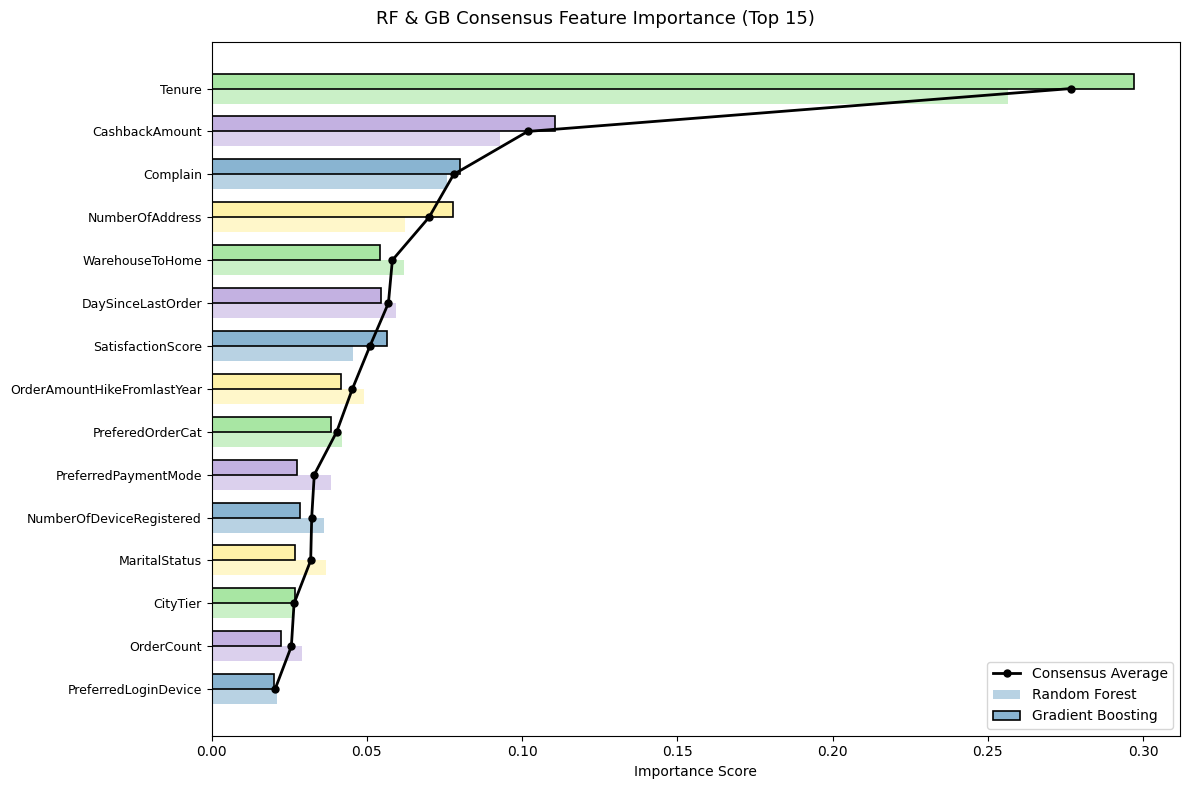

Top 10 Features by Consensus Importance:
                    Feature  Average Importance
                     Tenure            0.276832
             CashbackAmount            0.101776
                   Complain            0.077945
            NumberOfAddress            0.070011
            WarehouseToHome            0.058189
          DaySinceLastOrder            0.056922
          SatisfactionScore            0.050982
OrderAmountHikeFromlastYear            0.045318
           PreferedOrderCat            0.040263
       PreferredPaymentMode            0.033038


In [ ]:
# Instead of trusting one model's feature ranking, we average importance scores
# from Random Forest and Gradient Boosting — our two strongest tree-based models.
#
# Why consensus?
#   → Features that rank high in BOTH models are genuinely important
#   → Features that rank high in only one may reflect that model's bias
#   → This consensus ranking directly feeds our business recommendations
#
# How importance is computed per model:
#   Tree models → .feature_importances_: average reduction in impurity per feature
#   Logistic Regression → abs(coef_): coefficient magnitude after scaling
#   (We only use RF + GB for consensus since they're the most reliable)
feature_names = list(X.columns)

rf_imp  = tuned_results['Random Forest']['model'].feature_importances_
gb_imp  = tuned_results['Gradient Boosting']['model'].feature_importances_
avg_imp = (rf_imp + gb_imp) / 2   # Equal weight to both models

feat_df = pd.DataFrame({
    'Feature'          : feature_names,
    'Random Forest'    : rf_imp,
    'Gradient Boosting': gb_imp,
    'Average'          : avg_imp
}).sort_values('Average', ascending=True).tail(15)   # Show top 15

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('RF & GB Consensus Feature Importance (Top 15)', fontsize=13)

y_pos = range(len(feat_df))

# Green = Random Forest, Red = Gradient Boosting, Gold line = consensus average
ax.barh(y_pos, feat_df['Random Forest'], 0.35, align='edge',
        color=model_colors, alpha=0.6, label='Random Forest')
ax.barh([y + 0.35 for y in y_pos], feat_df['Gradient Boosting'], 0.35, align='edge',
        color=model_colors, alpha=1.0, edgecolor='black', linewidth=1.2,
        label='Gradient Boosting')
ax.plot(feat_df['Average'], [y + 0.35 for y in y_pos],
        'o-', color='black', lw=2, markersize=5, label='Consensus Average', zorder=5)

ax.set_yticks([y + 0.35 for y in y_pos])
ax.set_yticklabels(feat_df['Feature'], fontsize=9)
ax.set_xlabel('Importance Score')
ax.legend()

plt.tight_layout()
plt.show()

# Top 10 printed table — used to justify business recommendations
top10 = pd.DataFrame({'Feature': feature_names, 'Average Importance': avg_imp})\
          .sort_values('Average Importance', ascending=False).head(10)
print('Top 10 Features by Consensus Importance:')
print(top10.to_string(index=False))
# Business reading key:
#   #1 feature → WHEN to intervene (Tenure → early lifecycle)
#   #2 feature → HOW to intervene (Complain → complaint resolution)
#   #3 feature → WHAT tool to use (CashbackAmount → pricing incentives)

## Section 11 – Business Insights

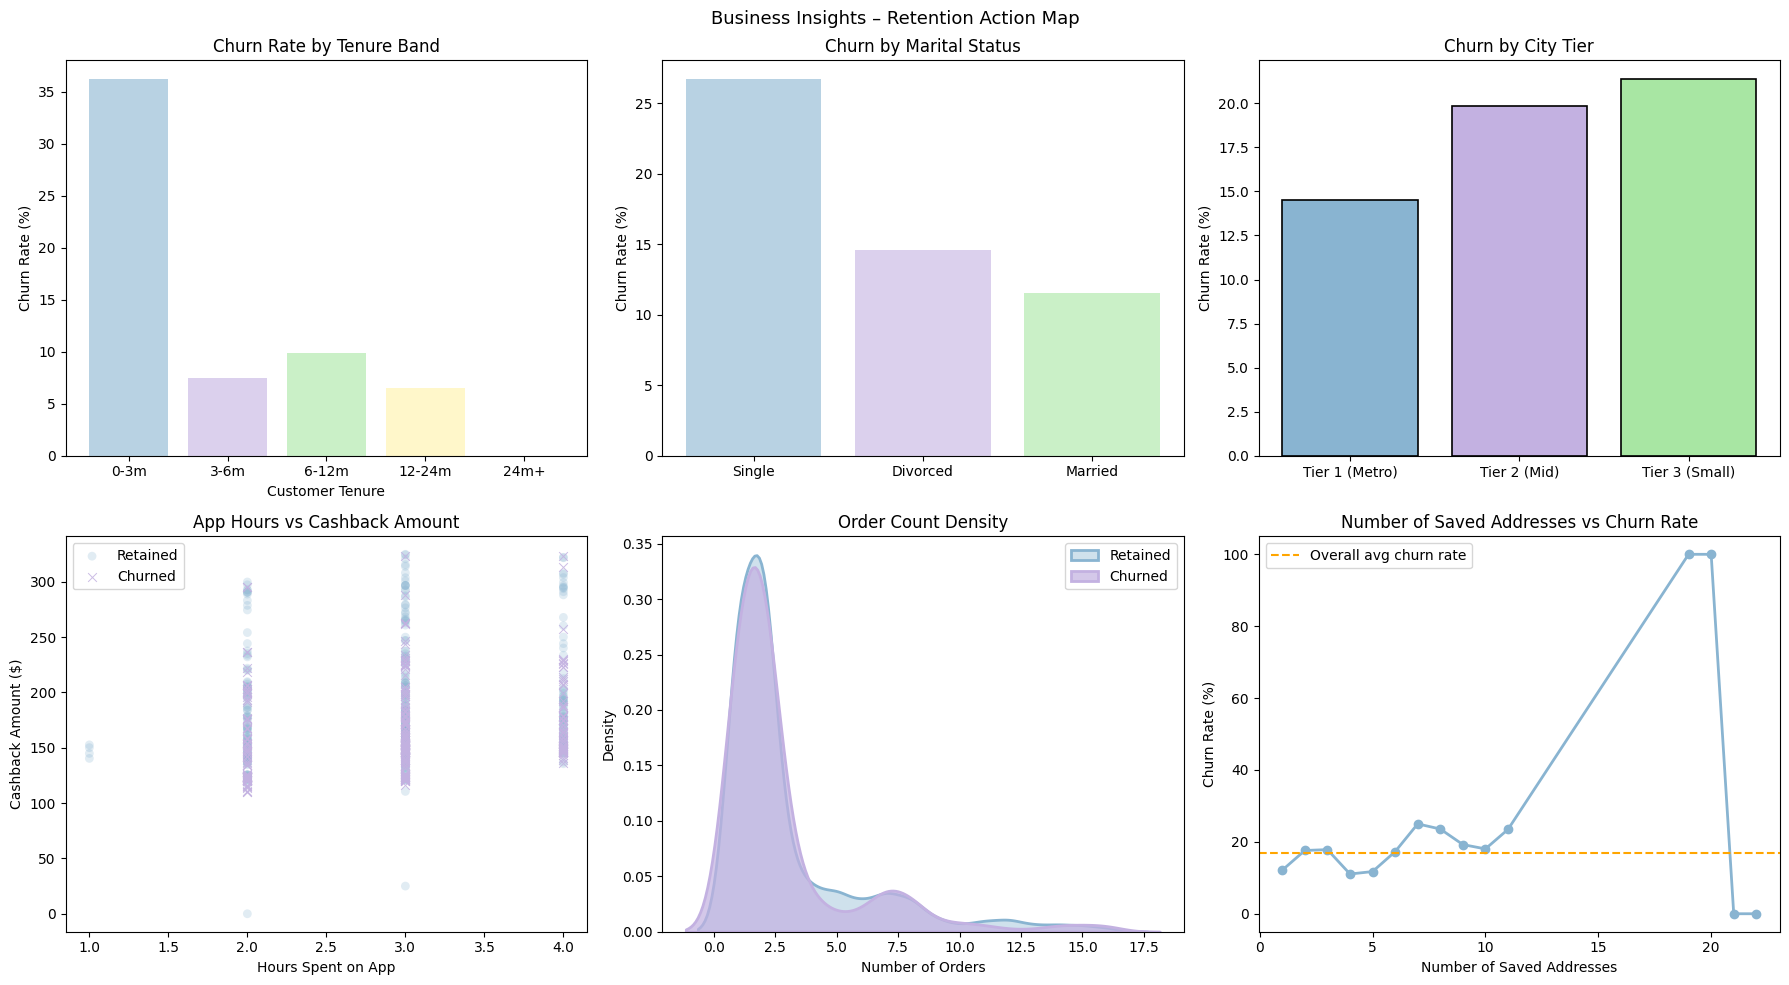

In [ ]:
# Each chart answers a specific business question derived from our EDA
# and feature importance findings. Together they form the evidence base
# for the retention strategy recommendations that follow.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Business Insights – Retention Action Map', fontsize=13)
axes = axes.flatten()

# ── Chart 1: Churn Rate by Tenure Band ────────────────────────────────────
# Segments customers into 5 lifecycle stages.
# WHEN do customers leave? This tells us exactly which window to target.
df['TenureBand'] = pd.cut(df['Tenure'].fillna(df['Tenure'].median()),
                           bins=[0, 3, 6, 12, 24, 100],
                           labels=['0-3m', '3-6m', '6-12m', '12-24m', '24m+'])
ten_churn = df.groupby('TenureBand', observed=True)['Churn'].mean() * 100
axes[0].bar(ten_churn.index.astype(str), ten_churn.values, color=model_colors, alpha=0.6)
axes[0].set_title('Churn Rate by Tenure Band')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Customer Tenure')
# Insight: 0-3 month customers churn most → onboarding is the critical window.

# ── Chart 2: Churn by Marital Status ──────────────────────────────────────
# WHO churns? Different lifestyle segments have different loyalty patterns.
mar_churn = df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False) * 100
axes[1].bar(mar_churn.index, mar_churn.values, color=model_colors, alpha=0.6)
axes[1].set_title('Churn by Marital Status')
axes[1].set_ylabel('Churn Rate (%)')
# Insight: single customers churn more → target with social/community features.

# ── Chart 3: Churn by City Tier ───────────────────────────────────────────
# WHERE is churn highest? City Tier reflects urban density and service quality.
# Tier 1 = metro, Tier 2 = mid-size, Tier 3 = small cities.
city_churn = df.groupby('CityTier')['Churn'].mean() * 100

# Insight: if Tier 3 is highest → logistics gaps are driving churn in smaller cities.
axes[2].bar(['Tier 1 (Metro)', 'Tier 2 (Mid)', 'Tier 3 (Small)'], city_churn.values,
            color=model_colors, alpha=1.0, edgecolor='black', linewidth=1.2)

axes[2].set_title('Churn by City Tier')
axes[2].set_ylabel('Churn Rate (%)')

# ── Chart 4: App Hours vs Cashback (Scatter) ──────────────────────────────
# Do engagement + incentives together predict retention?
# We sample to avoid overplotting (400 points per class max).
for i, (v, l, m) in enumerate([(0, 'Retained', 'o'), (1, 'Churned', 'x')]):
    sub = df[df['Churn'] == v].sample(min(400, len(df[df['Churn'] == v])), random_state=42)
    c = model_colors[i] if isinstance(model_colors, list) else model_colors
    # High contrast: Retained is faint/transparent, Churned is bold with an outline
    a = 0.25 if v == 0 else 0.85
    axes[3].scatter(sub['HourSpendOnApp'], sub['CashbackAmount'],
                    color=c, alpha=a, s=40, label=l, marker=m,
                    edgecolors='black' if v == 1 else 'none', linewidth=0.7)
axes[3].set_title('App Hours vs Cashback Amount')
axes[3].set_xlabel('Hours Spent on App')
axes[3].set_ylabel('Cashback Amount ($)')
axes[3].legend()
# Insight: churners clustering in low-cashback zone → personalized offers could retain them.

# ── Chart 5: Order Count Density (KDE) ────────────────────────────────────
# Do churners order less before leaving? This informs re-engagement timing.
import seaborn as sns
for i, (v, l) in enumerate([(0, 'Retained'), (1, 'Churned')]):
    c = model_colors[i] if isinstance(model_colors, list) else model_colors
    # KDE is much clearer than overlapping bars for seeing distribution shifts
    sns.kdeplot(df[df['Churn'] == v]['OrderCount'].dropna(),
                ax=axes[4], fill=True, color=c, label=l,
                alpha=0.4 if v == 0 else 0.7, linewidth=2)
axes[4].set_title('Order Count Density')
axes[4].set_xlabel('Number of Orders')
axes[4].set_ylabel('Density')
axes[4].legend()
# Insight: if churners have fewer orders → trigger re-engagement before order count drops to 0.

# ── Chart 6: Number of Addresses vs Churn Rate ────────────────────────────
# Customers with more saved addresses are more embedded in the platform.
# The orange dashed line = overall average churn rate for context.
addr_churn = df.groupby('NumberOfAddress')['Churn'].mean() * 100
axes[5].plot(addr_churn.index, addr_churn.values, 'o-', color=model_colors[0] if isinstance(model_colors, list) else model_colors, lw=2)
axes[5].axhline(df['Churn'].mean() * 100, color='orange', ls='--', label='Overall avg churn rate')
axes[5].set_title('Number of Saved Addresses vs Churn Rate')
axes[5].set_xlabel('Number of Saved Addresses')
axes[5].set_ylabel('Churn Rate (%)')
axes[5].legend()
# Insight: encouraging customers to save multiple addresses = deeper platform embedding = lower churn.

plt.tight_layout()
plt.show()


## Section 12 – Final Summary and Best Model

In [ ]:
# Full pipeline summary + detailed classification report for the winning model.
#
# How to read the classification report:
#   Precision (Churned) → of all customers we flagged as churning, X% actually did
#   Recall    (Churned) → of all customers who actually churned, we caught X%
#   F1 Score            → balance between Precision and Recall
#   Support             → number of actual instances per class in the test set
#
# For business use, RECALL on Churned is the most critical:
#   A missed churner (FN) = revenue lost with no intervention attempt.

best_res = tuned_results[best_name]

print('=' * 60)
print('        FINAL PIPELINE SUMMARY')
print('=' * 60)
print('Dataset    : 5,630 customers × 20 features → 22 after engineering')
print('Train/Test : 4,504 / 1,126  (stratified 80/20 split)')
print('Scaling    : RobustScaler applied to Logistic Regression only')
print('Tuning     : GridSearchCV, 5-fold CV, optimized for ROC-AUC')
print()

print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10} {"F1":>8}')
print('-' * 60)
for n, res in sorted(tuned_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    star = '  ← BEST' if n == best_name else ''
    print(f'{n:<25} {res["accuracy"]*100:>9.2f}% {res["roc_auc"]:>10.4f} {res["f1"]:>8.4f}{star}')

print(f'\nWinner     : {best_name}')
print(f'Accuracy   : {best_res["accuracy"]*100:.2f}%')
print(f'ROC-AUC    : {best_res["roc_auc"]:.4f}')
print(f'F1 Score   : {best_res["f1"]:.4f}')
print(f'Best Params: {best_params_all[best_name]}')

print(f'\nDetailed Classification Report – {best_name}:')
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['Retained (0)', 'Churned (1)']))

        FINAL PIPELINE SUMMARY
Dataset    : 5,630 customers × 20 features → 22 after engineering
Train/Test : 4,504 / 1,126  (stratified 80/20 split)
Scaling    : RobustScaler applied to Logistic Regression only
Tuning     : GridSearchCV, 5-fold CV, optimized for ROC-AUC

Model                       Accuracy    ROC-AUC       F1
------------------------------------------------------------
Gradient Boosting             98.76%     0.9988   0.9624  ← BEST
Random Forest                 94.76%     0.9885   0.8207
Decision Tree                 92.63%     0.9582   0.7662
Logistic Regression           88.01%     0.8672   0.5631

Winner     : Gradient Boosting
Accuracy   : 98.76%
ROC-AUC    : 0.9988
F1 Score   : 0.9624
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Detailed Classification Report – Gradient Boosting:
              precision    recall  f1-score   support

Retained (0)       0.99      1.00      0.99       936
 Churned (1)       0.98     